In [100]:
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os

In [101]:
load_dotenv()

labels_path = os.getenv('labels_path')
paths_path = os.getenv('paths_path')
boxes_path = os.getenv('boxes_path')

In [102]:
labels = pd.read_csv(labels_path)
paths = pd.read_csv(paths_path)

data = pd.merge(labels, paths, on=['PatientID', 'StudyUID', 'View'])
data.info()
data.head()


<class 'pandas.DataFrame'>
RangeIndex: 1163 entries, 0 to 1162
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   PatientID         1163 non-null   str  
 1   StudyUID          1163 non-null   str  
 2   View              1163 non-null   str  
 3   Normal            1163 non-null   int64
 4   Actionable        1163 non-null   int64
 5   Benign            1163 non-null   int64
 6   Cancer            1163 non-null   int64
 7   descriptive_path  1163 non-null   str  
 8   classic_path      1163 non-null   str  
dtypes: int64(4), str(5)
memory usage: 81.9 KB


,PatientID,StudyUID,View,Normal,Actionable,Benign,Cancer,descriptive_path,classic_path
0,DBT-P00714,DBT-S01360,rcc,0,0,0,1,Breast-Cancer-Screening-DBT/DBT-P00714/01-01-2...,Breast-Cancer-Screening-DBT/DBT-P00714/1.2.826...
1,DBT-P00714,DBT-S01360,rmlo,0,0,0,1,Breast-Cancer-Screening-DBT/DBT-P00714/01-01-2...,Breast-Cancer-Screening-DBT/DBT-P00714/1.2.826...
2,DBT-P03598,DBT-S03655,rcc,0,0,0,1,Breast-Cancer-Screening-DBT/DBT-P03598/01-01-2...,Breast-Cancer-Screening-DBT/DBT-P03598/1.2.826...
3,DBT-P03598,DBT-S03655,rmlo,0,0,0,1,Breast-Cancer-Screening-DBT/DBT-P03598/01-01-2...,Breast-Cancer-Screening-DBT/DBT-P03598/1.2.826...
4,DBT-P03621,DBT-S03266,lcc,0,0,0,1,Breast-Cancer-Screening-DBT/DBT-P03621/01-01-2...,Breast-Cancer-Screening-DBT/DBT-P03621/1.2.826...


In [103]:
class_map = {'Normal': 0, 'Actionable': 1, 'Benign': 2, 'Cancer': 3}
class_cols = ['Normal', 'Actionable', 'Benign', 'Cancer']
data['ClassCode'] = data[class_cols].idxmax(axis=1).map(class_map)

data.head(2)

,PatientID,StudyUID,View,Normal,Actionable,Benign,Cancer,descriptive_path,classic_path,ClassCode
0,DBT-P00714,DBT-S01360,rcc,0,0,0,1,Breast-Cancer-Screening-DBT/DBT-P00714/01-01-2...,Breast-Cancer-Screening-DBT/DBT-P00714/1.2.826...,3
1,DBT-P00714,DBT-S01360,rmlo,0,0,0,1,Breast-Cancer-Screening-DBT/DBT-P00714/01-01-2...,Breast-Cancer-Screening-DBT/DBT-P00714/1.2.826...,3


- **View:**

    - rcc = Right Craniocaundal (Uma visão da mama capturada diretamente de cima para baixo.)
    - lcc = Left Craniocaudal
    - rmlo = Right Mediolateral Oblíqua (Uma visão capturada em um ângulo diagonal, que geralmente inclui parte do músculo peitoral e se estende até a axila.)
    - lmlo = Left Mediolateral Oblíqua

- **ClassCode**:
    - Laudos normais (Normal: 0)
    - Casos que exigiram acompanhamento (Actionable: 1)
    - Tumores benignos comprovados por biópsia (Benign: 2)
    - Casos de câncer comprovados por biópsia (Cancer: 3)

In [104]:
patients = data['PatientID'].nunique()

print(f'Total number of patients: {patients}')

Total number of patients: 280


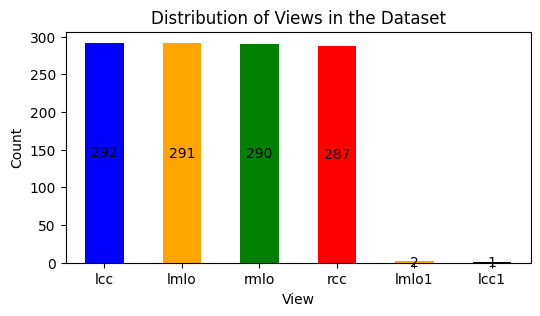

In [105]:
view_counts = data['View'].value_counts()

plt.figure(figsize=(6, 3))
ax = view_counts.plot(kind='bar', color=['blue', 'orange', 'green', 'red', 'orange', 'black'])
plt.title('Distribution of Views in the Dataset')
plt.bar_label(ax.containers[0], label_type="center")
plt.xlabel('View')
plt.ylabel('Count')
plt.xticks(ticks=range(len(view_counts.index)), labels=view_counts.index, rotation=0)
plt.show()

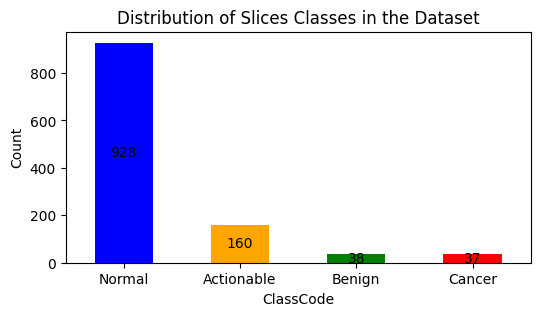

In [106]:
class_counts = data['ClassCode'].value_counts()

plt.figure(figsize=(6, 3))
ax = class_counts.plot(kind='bar', color=['blue', 'orange', 'green', 'red'])
plt.title('Distribution of Slices Classes in the Dataset')
plt.bar_label(ax.containers[0], label_type="center")
plt.xlabel('ClassCode')
plt.ylabel('Count')
plt.xticks(ticks=range(len(class_map)), labels=class_map.keys(), rotation=0)
plt.show()

In [107]:
boxes = pd.read_csv(boxes_path)
boxes.info()

<class 'pandas.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   PatientID     75 non-null     str  
 1   StudyUID      75 non-null     str  
 2   View          75 non-null     str  
 3   Subject       75 non-null     int64
 4   Slice         75 non-null     int64
 5   X             75 non-null     int64
 6   Y             75 non-null     int64
 7   Width         75 non-null     int64
 8   Height        75 non-null     int64
 9   Class         75 non-null     str  
 10  AD            75 non-null     int64
 11  VolumeSlices  75 non-null     int64
dtypes: int64(8), str(4)
memory usage: 7.2 KB


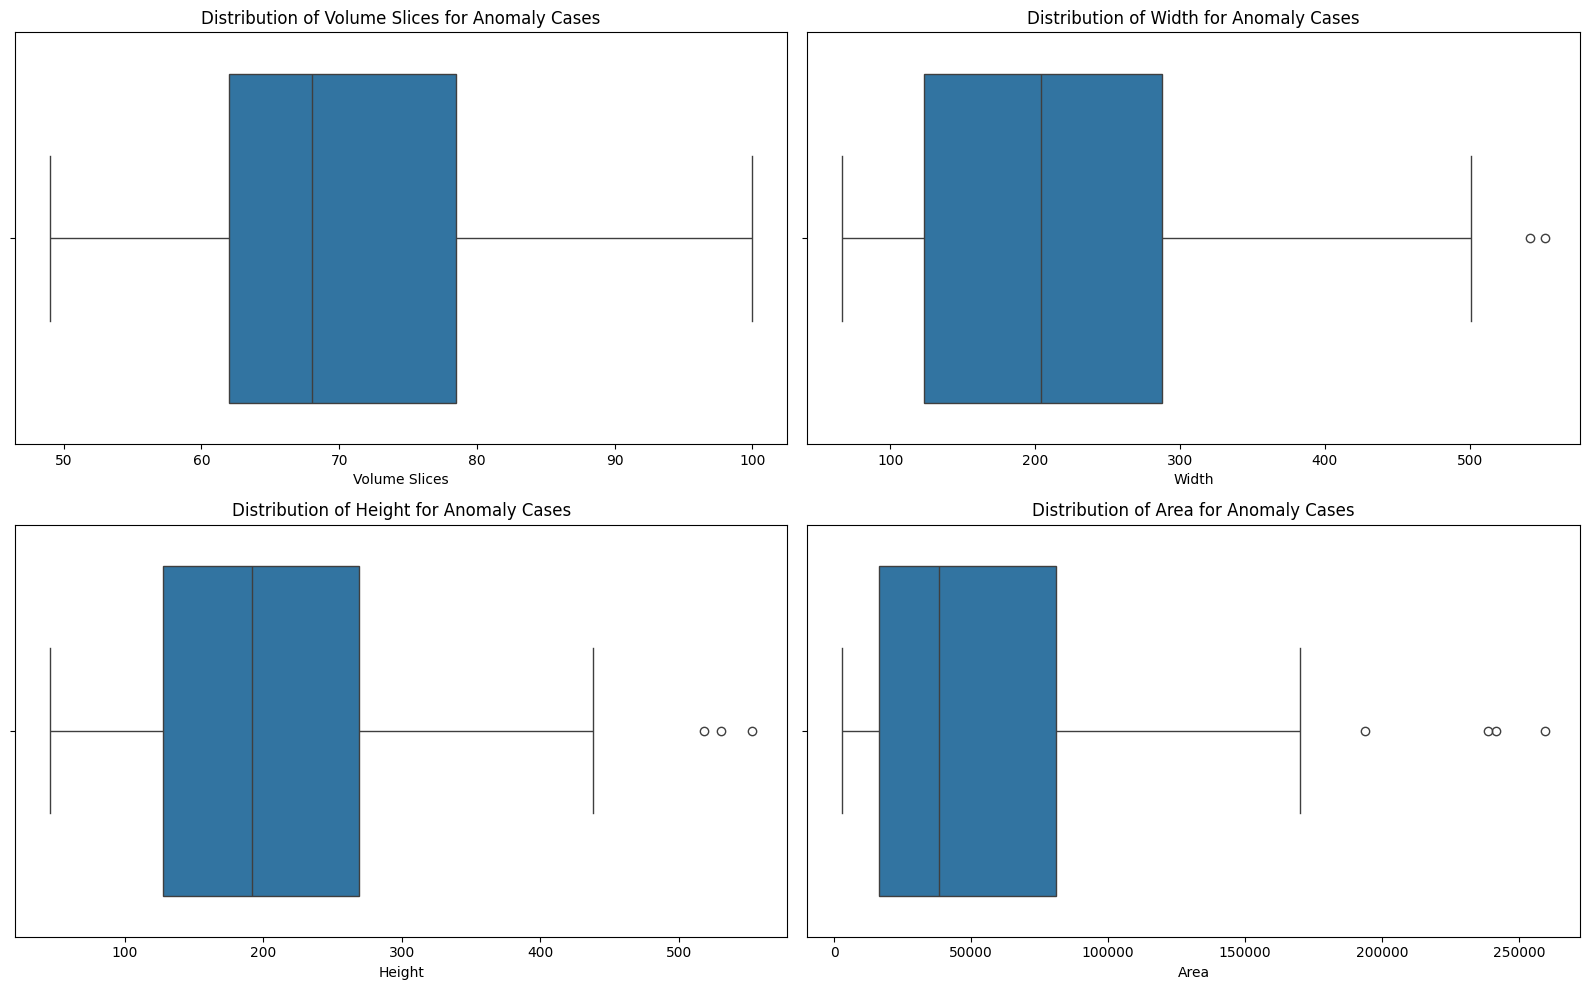

In [119]:
import seaborn as sns

anomaly_data = boxes[boxes['Class'].isin(['cancer', 'benign'])]
anomaly_data['Area'] = anomaly_data['Height'] * anomaly_data['Width']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(x=anomaly_data['VolumeSlices'], ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Volume Slices for Anomaly Cases')
axes[0, 0].set_xlabel('Volume Slices')

sns.boxplot(x=anomaly_data['Width'], ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Width for Anomaly Cases')
axes[0, 1].set_xlabel('Width')

sns.boxplot(x=anomaly_data['Height'], ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Height for Anomaly Cases')
axes[1, 0].set_xlabel('Height')

sns.boxplot(x=anomaly_data['Area'], ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Area for Anomaly Cases')
axes[1, 1].set_xlabel('Area')


plt.tight_layout()
plt.show()


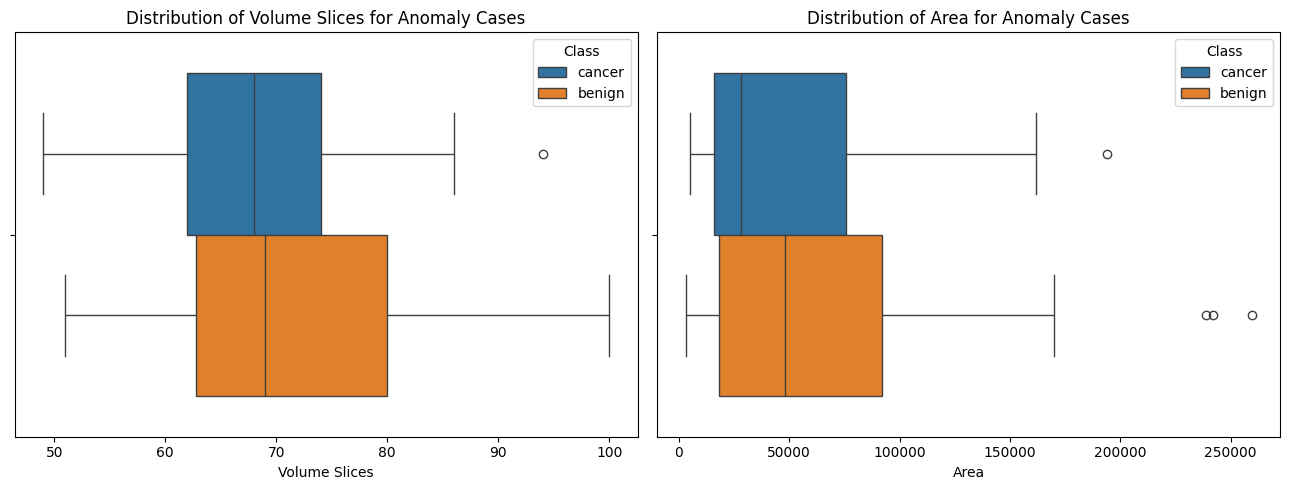

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(
    data=anomaly_data, 
    x="VolumeSlices", 
    hue="Class", 
    ax=axes[0]
)
axes[0].set_title('Distribution of Volume Slices for Anomaly Cases')
axes[0].set_xlabel('Volume Slices')

sns.boxplot(
    data=anomaly_data, 
    x="Area", 
    hue="Class", 
    ax=axes[1]
)
axes[1].set_title('Distribution of Area for Anomaly Cases')
axes[1].set_xlabel('Area')

plt.tight_layout()
plt.show()

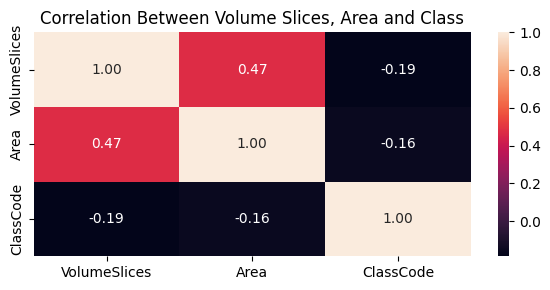

In [135]:
class_map = {'cancer': 1, 'benign': 0}
anomaly_data['ClassCode'] = boxes['Class'].map(class_map)

corr_data = anomaly_data[['VolumeSlices','Area', 'ClassCode']].corr()

plt.figure(figsize=(6, 3))
sns.heatmap(
    corr_data, 
    annot=True,         
    fmt=".2f",          
)

plt.title('Correlation Between Volume Slices, Area and Class')
plt.tight_layout()
plt.show()